# Data Exploration - Step-by-Step Guide for Beginners

## What is Data Exploration?

Data exploration is like **investigating a crime scene** before solving the case. Before we can predict race results, we need to:
1. **Understand** what data we have
2. **Find patterns** that might help predictions
3. **Check quality** - are there errors or missing values?
4. **Visualize** trends with charts and graphs

## Why Do We Do This?

Imagine trying to predict who will win a race without knowing:
- Who the riders are
- How many races we have
- If some riders always win
- If qualifying position matters

Data exploration answers these questions **before** we build any models.

---

## Step 1: Import Libraries (Tools We Need)

Think of libraries as **toolboxes**:
- `pandas` = Excel on steroids (for working with tables)
- `numpy` = Calculator for large datasets
- `matplotlib` & `seaborn` = Chart makers
- `pathlib` = File finder

In [1]:
# Import pandas - our main tool for working with data tables
import pandas as pd

# Import numpy - helps with math calculations
import numpy as np

# Import plotting libraries - for creating charts
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Pretty plots

# Import Path - helps find files
from pathlib import Path

# Set the style for our charts (makes them look nice)
sns.set_style('whitegrid')

# Set default figure size (width=12 inches, height=6 inches)
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## Step 2: Load the Data

**What we're doing:** Reading the CSV file (like opening an Excel file)

**CSV = Comma Separated Values** - a simple file format where:
- Each row is a race result
- Columns are separated by commas
- Example: `year,rider,position` → `2025,Chase Sexton,1`

In [2]:
# Define the path to our data file
# '../' means go up one folder from 'notebooks' to the main project folder
data_path = Path('../data/raw/sx_all_results.csv')

# Read the CSV file into a DataFrame (think of it as an Excel table)
df = pd.read_csv(data_path)

# Print how many rows (records) we have
print(f"Total records loaded: {len(df):,}")  # :, adds commas (19,861 instead of 19861)

# Print the column names
print(f"\nColumns in our data:")
for col in df.columns:
    print(f"  - {col}")

# Show the first 10 rows to see what the data looks like
print("\nFirst 10 rows:")
df.head(10)

Total records loaded: 19,861

Columns in our data:
  - year
  - round
  - date
  - race
  - class
  - event_type
  - position
  - rider
  - number
  - bike
  - time_or_points
  - url

First 10 rows:


,year,round,date,race,class,event_type,position,rider,number,bike,time_or_points,url
0,2023,17,"May 14, 2023",Salt Lake City,450sx,overall,1,Chase Sexton,23,Honda,25 Laps,https://mxgpresults.com/sx/2023/salt-lake-city/
1,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,1,Chase Sexton,23,Honda,25 Laps,https://mxgpresults.com/sx/2023/salt-lake-city/
2,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,2,Aaron Plessinger,7,KTM,+18.266,https://mxgpresults.com/sx/2023/salt-lake-city/
3,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,3,Justin Hill,46,KTM,+21.400,https://mxgpresults.com/sx/2023/salt-lake-city/
4,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,4,Adam Cianciarulo,9,Kawasaki,+24.998,https://mxgpresults.com/sx/2023/salt-lake-city/
5,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,5,Dean Wilson,15,Honda,+28.359,https://mxgpresults.com/sx/2023/salt-lake-city/
6,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,6,Josh Hill,751,KTM,24 Laps,https://mxgpresults.com/sx/2023/salt-lake-city/
7,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,7,Shane McElrath,12,Suzuki,+4.410,https://mxgpresults.com/sx/2023/salt-lake-city/
8,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,8,Justin Starling,60,GASGAS,+15.941,https://mxgpresults.com/sx/2023/salt-lake-city/
9,2023,17,"May 14, 2023",Salt Lake City,450sx,main_event,9,Devin Simonson,170,Kawasaki,+23.173,https://mxgpresults.com/sx/2023/salt-lake-city/


### Understanding the Columns

Let's explain what each column means:

| Column | What It Means | Example |
|--------|---------------|----------|
| **year** | Season year | 2025 |
| **round** | Race number in season | 1 (first race), 17 (last race) |
| **date** | When the race happened | "January 11, 2025" |
| **race** | Location name | "Anaheim 1" |
| **class** | Bike category | 450sx, 250sxe, 250sxw |
| **event_type** | Type of race | main_event, qualifying, heat_1, etc. |
| **position** | Finishing position | 1 (winner), 2 (second), etc. |
| **rider** | Rider's name | "Chase Sexton" |
| **number** | Bike number | 23 |
| **bike** | Manufacturer | Honda, KTM, Yamaha, etc. |
| **time_or_points** | Time behind winner or laps completed | "+5.2" or "25 Laps" |
| **url** | Source webpage | Link to race results |

---

## Step 3: Basic Statistics (Getting to Know Our Data)

**What we're doing:** Counting and summarizing the data

**Why:** To understand the scope of what we're working with

In [3]:
# Print a nice header
print("=" * 70)
print("DATA SUMMARY")
print("=" * 70)

# Get unique years (sorted from oldest to newest)
years = sorted(df['year'].unique())
print(f"\nYears covered: {years}")
print(f"  → We have {len(years)} seasons of data")

# Get unique classes
classes = sorted(df['class'].unique())
print(f"\nClasses: {classes}")
print(f"  → 450sx = 450cc bikes (bigger, more powerful)")
print(f"  → 250sxe = 250cc East series (smaller bikes)")
print(f"  → 250sxw = 250cc West series (smaller bikes)")

# Get unique event types
event_types = sorted(df['event_type'].unique())
print(f"\nEvent types: {event_types}")
print(f"  → We track multiple events per race (qualifying, heats, main event)")

# Count unique races
num_races = df['race'].nunique()  # nunique() = count unique values
print(f"\nTotal unique races: {num_races}")

# Count unique riders
num_riders = df['rider'].nunique()
print(f"Total unique riders: {num_riders}")

# Total records
print(f"Total results: {len(df):,}")
print(f"  → Each result is one rider in one event")

DATA SUMMARY

Years covered: [np.int64(2023), np.int64(2024), np.int64(2025)]
  → We have 3 seasons of data

Classes: ['250sxe', '250sxw', '450sx']
  → 450sx = 450cc bikes (bigger, more powerful)
  → 250sxe = 250cc East series (smaller bikes)
  → 250sxw = 250cc West series (smaller bikes)

Event types: ['heat_1', 'heat_2', 'heat_east', 'heat_west', 'lcq', 'main_event', 'overall', 'qualifying', 'race_1', 'race_2', 'race_3']
  → We track multiple events per race (qualifying, heats, main event)

Total unique races: 23
Total unique riders: 217
Total results: 19,861
  → Each result is one rider in one event


### Breaking Down Results by Year and Class

**What we're doing:** Creating a table showing how many results we have for each year and class

**Why:** To check if we have balanced data (not missing a whole season or class)

In [4]:
print("\n" + "=" * 70)
print("RESULTS BY YEAR AND CLASS")
print("=" * 70)

# Group by year and class, count how many results
# .unstack() pivots the data to make a nice table
# fill_value=0 replaces missing values with 0
results_by_year_class = df.groupby(['year', 'class']).size().unstack(fill_value=0)

print(results_by_year_class)
print("\nHow to read this table:")
print("  - Rows = Years (2023, 2024, 2025)")
print("  - Columns = Classes (250sxe, 250sxw, 450sx)")
print("  - Numbers = How many results for that year/class combination")


RESULTS BY YEAR AND CLASS
class  250sxe  250sxw  450sx
year                        
2023     1634    1519   3065
2024     1664    1727   3342
2025     1877    1898   3135

How to read this table:
  - Rows = Years (2023, 2024, 2025)
  - Columns = Classes (250sxe, 250sxw, 450sx)
  - Numbers = How many results for that year/class combination


In [5]:
print("\n" + "=" * 70)
print("RESULTS BY EVENT TYPE")
print("=" * 70)

# Count how many results for each event type
# .value_counts() counts occurrences of each unique value
event_counts = df['event_type'].value_counts()

print(event_counts)
print("\nWhat these event types mean:")
print("  - qualifying: Time trials to determine starting positions")
print("  - heat_1/heat_2: Semi-final races")
print("  - lcq: Last Chance Qualifier (for riders who didn't qualify)")
print("  - main_event: The main race (what we want to predict!)")
print("  - overall: Combined results across multiple races")


RESULTS BY EVENT TYPE
event_type
qualifying    4462
lcq           3782
main_event    2879
heat_1        2761
heat_2        2720
race_2         611
race_3         611
race_1         593
heat_west      512
overall        496
heat_east      434
Name: count, dtype: int64

What these event types mean:
  - qualifying: Time trials to determine starting positions
  - heat_1/heat_2: Semi-final races
  - lcq: Last Chance Qualifier (for riders who didn't qualify)
  - main_event: The main race (what we want to predict!)
  - overall: Combined results across multiple races


## Step 4: Check for Missing Data

**What we're doing:** Looking for empty cells in our data

**Why:** Missing data can cause problems when training models. We need to know:
- Which columns have missing values?
- How many are missing?
- Should we fill them in or remove those rows?

In [6]:
print("Missing data check:")
print("=" * 70)

# .isnull() checks each cell - True if empty, False if has value
# .sum() counts how many True values (missing cells) per column
missing_counts = df.isnull().sum()

# Only show columns that have missing values
missing_data = missing_counts[missing_counts > 0]

if len(missing_data) > 0:
    print("\nColumns with missing values:")
    for col, count in missing_data.items():
        percentage = (count / len(df)) * 100
        print(f"  - {col}: {count:,} missing ({percentage:.1f}%)")
else:
    print("\n✓ No missing values found!")

# Check which races have missing dates
if 'date' in missing_data:
    print("\nRaces with missing dates:")
    missing_dates = df[df['date'].isnull()].groupby('year')['race'].value_counts()
    print(missing_dates.head(10))
    print("\n  → These are likely future races that haven't happened yet")

Missing data check:

Columns with missing values:
  - date: 2,426 missing (12.2%)

Races with missing dates:
year  race        
2025  Indianapolis    565
      Arlington       393
      Birmingham      393
      San Diego       362
      Anaheim 1       358
      Anaheim 2       355
Name: count, dtype: int64

  → These are likely future races that haven't happened yet


## Step 5: Focus on Main Events

**What we're doing:** Filtering the data to only main events

**Why:** The main event is what we want to predict. Qualifying and heats are useful for features, but our target is main event finishing position.

In [7]:
# Filter to only main events
# df['event_type'] == 'main_event' creates a True/False mask
# df[mask] keeps only rows where mask is True
main_events = df[df['event_type'] == 'main_event'].copy()

print("Main Event Statistics:")
print("=" * 70)
print(f"Main event results: {len(main_events):,}")
print(f"Races with main events: {main_events['race'].nunique()}")
print(f"Riders in main events: {main_events['rider'].nunique()}")

# Show breakdown by year and class
print("\nMain events by year and class:")
main_by_year_class = main_events.groupby(['year', 'class']).size().unstack(fill_value=0)
print(main_by_year_class)

Main Event Statistics:
Main event results: 2,879
Races with main events: 22
Riders in main events: 209

Main events by year and class:
class  250sxe  250sxw  450sx
year                        
2023      295     229    461
2024      263     249    429
2025      259     229    465


### Field Size Analysis

**What we're doing:** Counting how many riders compete in each race

**Why:** Field size affects competition level. A 22-rider field is more competitive than a 15-rider field.

In [8]:
# For each race, count how many riders competed
# groupby(['year', 'class', 'race']) groups results by unique race
# .size() counts riders in each group
field_sizes = main_events.groupby(['year', 'class', 'race']).size().reset_index(name='field_size')

print("Average field size by class:")
print("=" * 70)

# .describe() gives statistics: count, mean, std, min, max, etc.
field_stats = field_sizes.groupby('class')['field_size'].describe()
print(field_stats)

print("\nHow to read this:")
print("  - count: Number of races")
print("  - mean: Average number of riders per race")
print("  - std: Standard deviation (how much it varies)")
print("  - min/max: Smallest and largest fields")
print("  - 25%/50%/75%: Quartiles (percentiles)")

Average field size by class:
        count       mean       std   min   25%   50%   75%   max
class                                                           
250sxe   25.0  32.680000  0.945163  30.0  32.0  33.0  33.0  34.0
250sxw   22.0  32.136364  1.390288  29.0  32.0  32.5  33.0  34.0
450sx    41.0  33.048780  0.589543  31.0  33.0  33.0  33.0  34.0

How to read this:
  - count: Number of races
  - mean: Average number of riders per race
  - std: Standard deviation (how much it varies)
  - min/max: Smallest and largest fields
  - 25%/50%/75%: Quartiles (percentiles)


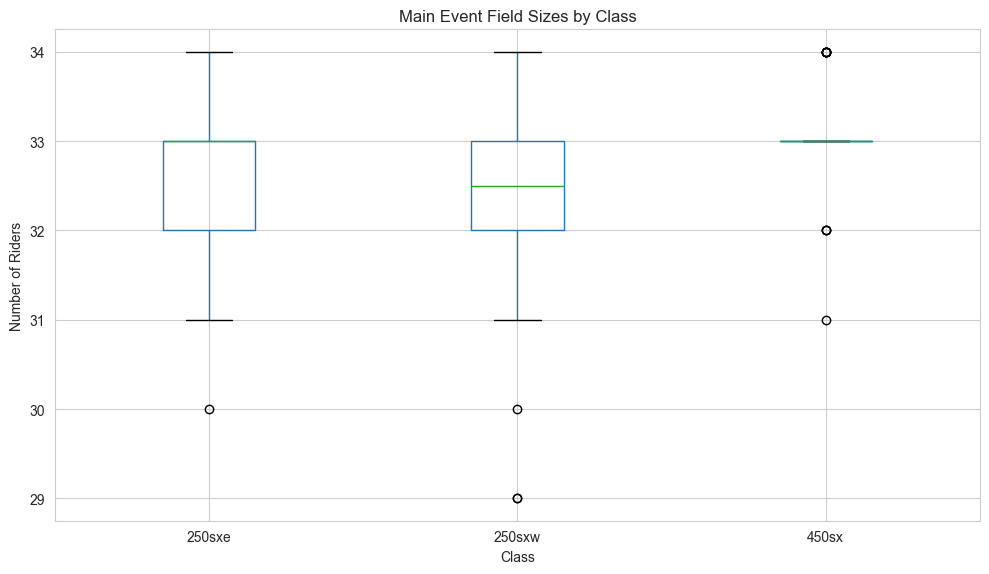


What this chart shows:
  - Each box represents one class (250sxe, 250sxw, 450sx)
  - Higher boxes = more riders per race
  - Taller boxes = more variation in field size


In [9]:
# Create a box plot to visualize field sizes
fig, ax = plt.subplots(figsize=(10, 6))

# Box plot shows distribution of data
# - Box = middle 50% of data
# - Line in box = median (middle value)
# - Whiskers = range of data
# - Dots = outliers (unusual values)
field_sizes.boxplot(column='field_size', by='class', ax=ax)

plt.suptitle('')  # Remove default title
plt.title('Main Event Field Sizes by Class')
plt.ylabel('Number of Riders')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

print("\nWhat this chart shows:")
print("  - Each box represents one class (250sxe, 250sxw, 450sx)")
print("  - Higher boxes = more riders per race")
print("  - Taller boxes = more variation in field size")

## Step 6: Rider Performance Analysis

**What we're doing:** Finding the best riders

**Why:** Understanding who wins helps us:
- Validate our data (do known champions show up?)
- Identify patterns (do same riders always win?)
- Create features (rider skill level)

In [11]:
# Find riders who finished 1st (winners)
# main_events['position'] == 1 creates a mask for winners only
winners = main_events[main_events['position'] == 1]

# Count wins per rider
# .groupby('rider') groups by rider name
# .size() counts how many wins
# .sort_values(ascending=False) sorts from most to least wins
wins = winners.groupby('rider').size().sort_values(ascending=False)

print("Top 15 Riders by Main Event Wins (2023-2025):")
print("=" * 70)
for i, (rider, win_count) in enumerate(wins.head(15).items(), 1):
    print(f"{i:2d}. {rider:25s} - {win_count} wins")

print("\nInsights:")
print(f"  - Most dominant rider: {wins.index[0]} with {wins.iloc[0]} wins")
print(f"  - Total riders with at least 1 win: {len(wins)}")
print(f"  - Average wins per winner: {wins.mean():.1f}")

Top 15 Riders by Main Event Wins (2023-2025):
 1. Chase Sexton              - 14 wins
 2. Jett Lawrence             - 12 wins
 3. Cooper Webb               - 8 wins
 4. Eli Tomac                 - 7 wins
 5. Hunter Lawrence           - 7 wins
 6. Haiden Deegan             - 6 wins
 7. Freddie Noren             - 5 wins
 8. Rj Hampshire              - 5 wins
 9. Coty Schock               - 5 wins
10. Max Anstie                - 4 wins
11. Gavin Towers              - 4 wins
12. Seth Hammaker             - 4 wins
13. Hunter Yoder              - 4 wins
14. Aaron Plessinger          - 3 wins
15. Justin Hill               - 3 wins

Insights:
  - Most dominant rider: Chase Sexton with 14 wins
  - Total riders with at least 1 win: 71
  - Average wins per winner: 2.5


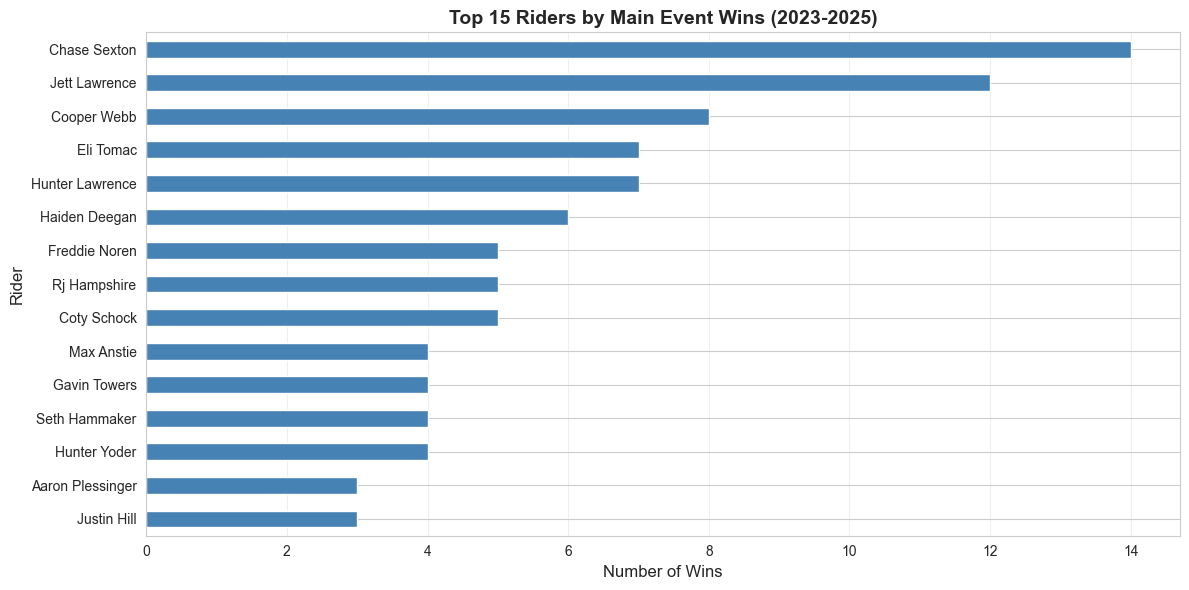


How to read this chart:
  - Longer bars = more wins
  - Top rider has the longest bar
  - Shows dominance of top riders


In [12]:
# Visualize top winners with a horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot top 15 winners
wins.head(15).plot(kind='barh', ax=ax, color='steelblue')

plt.title('Top 15 Riders by Main Event Wins (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Rider', fontsize=12)
plt.gca().invert_yaxis()  # Flip so #1 is at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHow to read this chart:")
print("  - Longer bars = more wins")
print("  - Top rider has the longest bar")
print("  - Shows dominance of top riders")

### Podium Finishes (Top 3)

**What we're doing:** Counting top-3 finishes

**Why:** Podiums show consistency. A rider might not win often but consistently finish top 3.

In [13]:
# Find all podium finishes (positions 1, 2, or 3)
podiums = main_events[main_events['position'] <= 3]

# Count podiums per rider
podium_counts = podiums.groupby('rider').size().sort_values(ascending=False)

print("Top 15 Riders by Podiums (Top 3 finishes):")
print("=" * 70)
for i, (rider, count) in enumerate(podium_counts.head(15).items(), 1):
    # Also show their wins
    rider_wins = wins.get(rider, 0)  # .get() returns 0 if rider not in wins
    print(f"{i:2d}. {rider:25s} - {count} podiums ({rider_wins} wins)")

print("\nInsights:")
print("  - Podiums show consistency (not just one-time winners)")
print("  - Riders with many podiums but few wins are consistent but not dominant")

Top 15 Riders by Podiums (Top 3 finishes):
 1. Chase Sexton              - 29 podiums (14 wins)
 2. Cooper Webb               - 26 podiums (8 wins)
 3. Haiden Deegan             - 17 podiums (6 wins)
 4. Jett Lawrence             - 17 podiums (12 wins)
 5. Tom Vialle                - 16 podiums (3 wins)
 6. Ken Roczen                - 15 podiums (3 wins)
 7. Rj Hampshire              - 15 podiums (5 wins)
 8. Eli Tomac                 - 14 podiums (7 wins)
 9. Jordon Smith              - 12 podiums (1 wins)
10. Kevin Moranz              - 11 podiums (1 wins)
11. Freddie Noren             - 11 podiums (5 wins)
12. Hunter Lawrence           - 10 podiums (7 wins)
13. Kyle Chisholm             - 10 podiums (2 wins)
14. Levi Kitchen              - 9 podiums (2 wins)
15. Cameron Mcadoo            - 9 podiums (0 wins)

Insights:
  - Podiums show consistency (not just one-time winners)
  - Riders with many podiums but few wins are consistent but not dominant


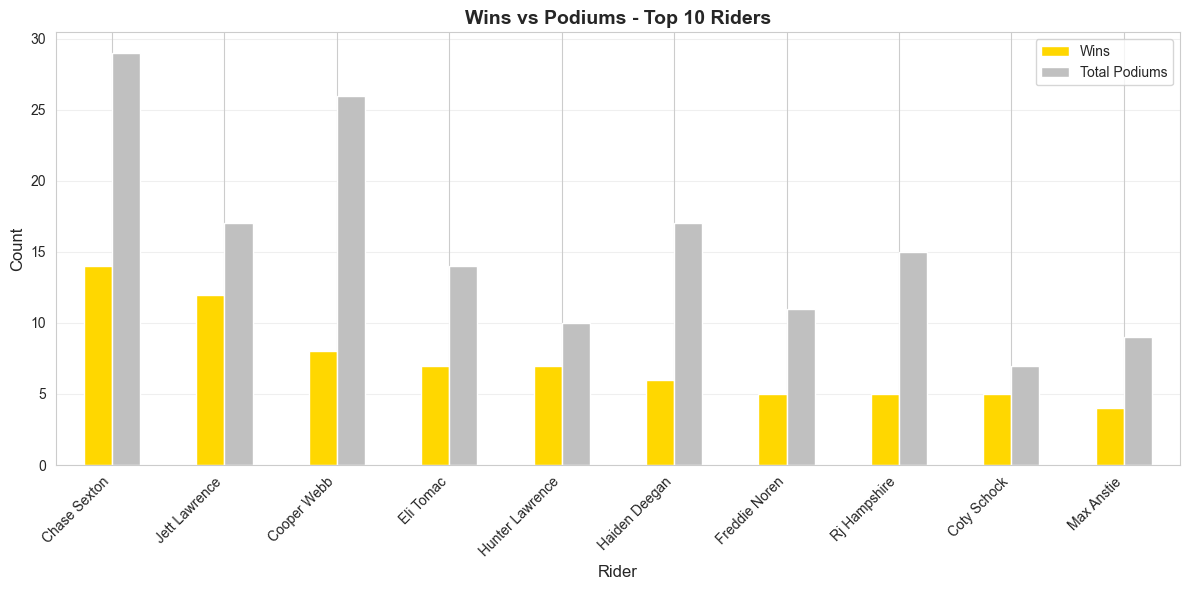


How to read this chart:
  - Gold bars = wins (1st place)
  - Silver bars = total podiums (1st, 2nd, or 3rd)
  - Silver always >= gold (podiums include wins)
  - Big gap = rider often finishes 2nd/3rd but doesn't win


In [15]:
# Compare wins vs podiums for top riders
top_riders = wins.head(10).index  # Get names of top 10 winners

# Create a DataFrame comparing wins and podiums
comparison = pd.DataFrame({
    'Wins': wins[top_riders],
    'Podiums': podium_counts[top_riders]
})

# Plot side-by-side bars
comparison.plot(kind='bar', figsize=(12, 6), color=['gold', 'silver'])
plt.title('Wins vs Podiums - Top 10 Riders', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Rider', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Wins', 'Total Podiums'], fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHow to read this chart:")
print("  - Gold bars = wins (1st place)")
print("  - Silver bars = total podiums (1st, 2nd, or 3rd)")
print("  - Silver always >= gold (podiums include wins)")
print("  - Big gap = rider often finishes 2nd/3rd but doesn't win")

### Average Finishing Position

**What we're doing:** Calculating each rider's average position

**Why:** Shows overall performance level. Average position of 5 means they typically finish mid-pack.

In [16]:
# Calculate statistics for each rider
# .agg() lets us calculate multiple statistics at once
rider_stats = main_events.groupby('rider').agg({
    'position': ['mean', 'median', 'std', 'count'],  # Position statistics
    'race': 'nunique'  # Count unique races (how many races they competed in)
}).round(2)  # Round to 2 decimal places

# Rename columns for clarity
rider_stats.columns = ['avg_position', 'median_position', 'std_position', 'total_races', 'unique_races']

# Filter to riders with at least 5 races (remove one-time riders)
rider_stats = rider_stats[rider_stats['total_races'] >= 5]

# Sort by average position (best riders first)
rider_stats = rider_stats.sort_values('avg_position')

print("Top 15 Riders by Average Finishing Position (min 5 races):")
print("=" * 70)
print(rider_stats.head(15))

print("\nColumn explanations:")
print("  - avg_position: Average finishing position (lower = better)")
print("  - median_position: Middle value (less affected by bad races)")
print("  - std_position: Consistency (lower = more consistent)")
print("  - total_races: How many times they raced")
print("  - unique_races: How many different race events")

Top 15 Riders by Average Finishing Position (min 5 races):
                    avg_position  median_position  std_position  total_races  \
rider                                                                          
Jett Lawrence               2.83              1.0          2.93           23   
Cooper Webb                 2.97              2.0          2.09           38   
Chase Sexton                3.47              2.0          3.65           43   
Cole Davies                 3.67              4.0          2.40            9   
Rj Hampshire                3.75              2.0          3.89           20   
Haiden Deegan               4.16              3.0          3.16           31   
Jo Shimoda                  5.24              4.0          4.17           25   
Eli Tomac                   5.28              5.0          5.01           29   
RJ Hampshire                5.60              3.5          5.64           10   
Hunter Lawrence             5.62              5.0          4.

## Step 7: Class-Specific Analysis

**What we're doing:** Looking at top riders in each class separately

**Why:** 450sx and 250sx are different competitions with different riders

In [17]:
# Analyze each class separately
for class_name in ['450sx', '250sxe', '250sxw']:
    # Filter to this class only
    class_data = main_events[main_events['class'] == class_name]
    
    # Count wins in this class
    class_wins = class_data[class_data['position'] == 1].groupby('rider').size().sort_values(ascending=False)
    
    print(f"\n{'='*70}")
    print(f"TOP 10 RIDERS - {class_name.upper()}")
    print(f"{'='*70}")
    
    for i, (rider, win_count) in enumerate(class_wins.head(10).items(), 1):
        print(f"{i:2d}. {rider:25s} - {win_count} wins")
    
    print(f"\nTotal races in {class_name}: {class_data['race'].nunique()}")
    print(f"Total riders in {class_name}: {class_data['rider'].nunique()}")


TOP 10 RIDERS - 450SX
 1. Chase Sexton              - 14 wins
 2. Cooper Webb               - 8 wins
 3. Jett Lawrence             - 8 wins
 4. Eli Tomac                 - 7 wins
 5. Freddie Noren             - 5 wins
 6. Aaron Plessinger          - 3 wins
 7. Grant Harlan              - 3 wins
 8. Justin Hill               - 3 wins
 9. Ken Roczen                - 3 wins
10. Joshua Cartwright         - 2 wins

Total races in 450sx: 21
Total riders in 450sx: 93

TOP 10 RIDERS - 250SXE
 1. Hunter Lawrence           - 7 wins
 2. Haiden Deegan             - 3 wins
 3. Coty Schock               - 3 wins
 4. Max Anstie                - 3 wins
 5. Seth Hammaker             - 3 wins
 6. Tom Vialle                - 3 wins
 7. Austin Forkner            - 2 wins
 8. Hardy Munoz               - 2 wins
 9. Chance Hymas              - 1 wins
10. Crockett Myers            - 1 wins

Total races in 250sxe: 14
Total riders in 250sxe: 119

TOP 10 RIDERS - 250SXW
 1. Rj Hampshire              - 4 wins
 2

## Step 8: Qualifying vs Main Event Correlation

**What we're doing:** Checking if qualifying position predicts main event finish

**Why:** This is a KEY question for our model:
- If correlation is high → qualifying is a strong predictor
- If correlation is low → other factors matter more

**Correlation** ranges from -1 to 1:
- 1.0 = perfect positive correlation (qual 1st always finishes 1st)
- 0.0 = no correlation (qualifying doesn't matter)
- -1.0 = perfect negative correlation (qual 1st always finishes last)

In [18]:
# Get qualifying results
qualifying = df[df['event_type'] == 'qualifying'][['year', 'round', 'race', 'class', 'rider', 'position']].copy()
qualifying.columns = ['year', 'round', 'race', 'class', 'rider', 'qual_position']

# Get main event results
main = main_events[['year', 'round', 'race', 'class', 'rider', 'position']].copy()
main.columns = ['year', 'round', 'race', 'class', 'rider', 'main_position']

# Merge them together (match same rider in same race)
# This is like doing a VLOOKUP in Excel
qual_vs_main = qualifying.merge(
    main, 
    on=['year', 'round', 'race', 'class', 'rider'],  # Match on these columns
    how='inner'  # Only keep rows that match in both tables
)

print(f"Matched qualifying-main event pairs: {len(qual_vs_main):,}")
print(f"  → These are riders who competed in both qualifying AND main event")

# Calculate correlation
# .corr() measures how closely two variables move together
correlation = qual_vs_main['qual_position'].corr(qual_vs_main['main_position'])

print(f"\nCorrelation between qualifying and main event position: {correlation:.3f}")

# Interpret the correlation
if correlation > 0.7:
    print("  → STRONG positive correlation - qualifying is very predictive!")
elif correlation > 0.4:
    print("  → MODERATE positive correlation - qualifying matters but isn't everything")
elif correlation > 0.2:
    print("  → WEAK positive correlation - qualifying has some effect")
else:
    print("  → VERY WEAK correlation - qualifying doesn't predict much")

Matched qualifying-main event pairs: 2,775
  → These are riders who competed in both qualifying AND main event

Correlation between qualifying and main event position: 0.210
  → WEAK positive correlation - qualifying has some effect


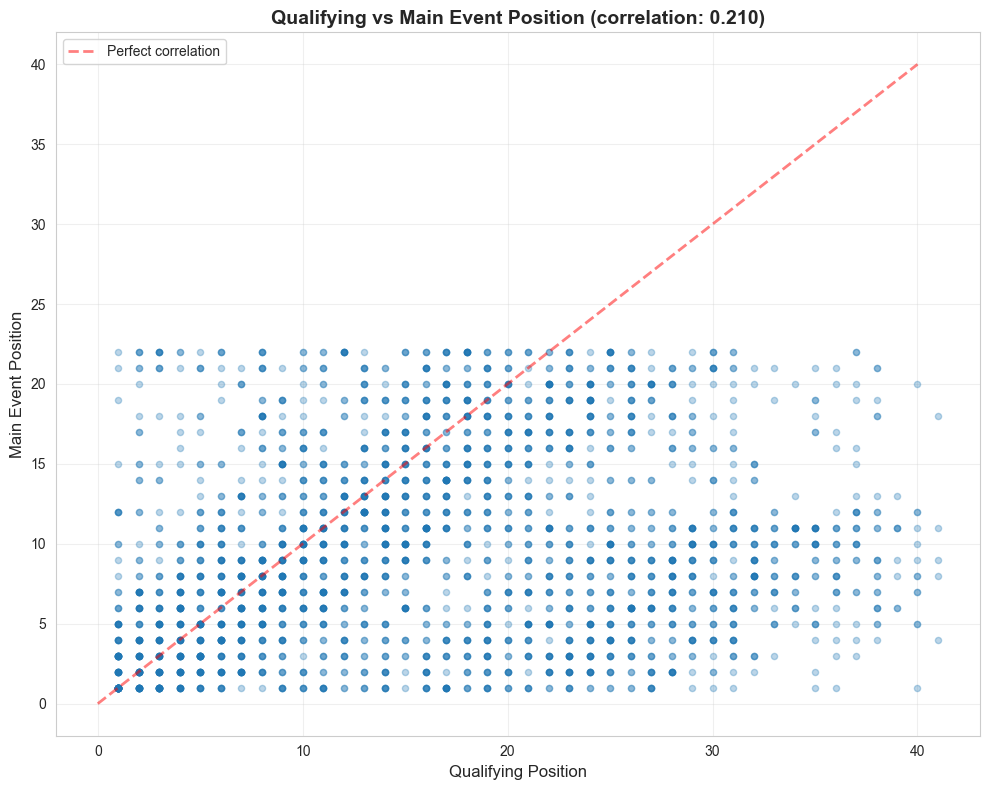


How to read this chart:
  - Each dot = one rider in one race
  - Dots near red line = qualifying position matched main event position
  - Dots above line = finished worse than qualified
  - Dots below line = finished better than qualified
  - Scattered dots = low correlation (qualifying doesn't predict well)
  - Tight cluster along line = high correlation (qualifying predicts well)


In [19]:
# Visualize the relationship with a scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Each dot represents one rider in one race
# x-axis = qualifying position
# y-axis = main event position
plt.scatter(
    qual_vs_main['qual_position'], 
    qual_vs_main['main_position'], 
    alpha=0.3,  # Make dots semi-transparent (so we can see overlaps)
    s=20  # Size of dots
)

plt.xlabel('Qualifying Position', fontsize=12)
plt.ylabel('Main Event Position', fontsize=12)
plt.title(f'Qualifying vs Main Event Position (correlation: {correlation:.3f})', 
          fontsize=14, fontweight='bold')

# Add a diagonal line showing perfect correlation
plt.plot([0, 40], [0, 40], 'r--', alpha=0.5, linewidth=2, label='Perfect correlation')

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHow to read this chart:")
print("  - Each dot = one rider in one race")
print("  - Dots near red line = qualifying position matched main event position")
print("  - Dots above line = finished worse than qualified")
print("  - Dots below line = finished better than qualified")
print("  - Scattered dots = low correlation (qualifying doesn't predict well)")
print("  - Tight cluster along line = high correlation (qualifying predicts well)")

## Step 9: Data Quality Check

**What we're doing:** Looking for problems in the data

**Why:** Bad data = bad predictions. We need to catch:
- Duplicate results (same rider listed twice)
- Missing positions
- Impossible values (position 0 or 100)

In [20]:
# Check for duplicate results (same rider in same race listed twice)
# .duplicated() marks rows that are duplicates
# subset= specifies which columns to check for duplicates
duplicates = main_events.duplicated(
    subset=['year', 'round', 'race', 'class', 'rider'], 
    keep=False  # Mark ALL duplicates (not just 2nd occurrence)
)

print(f"Duplicate main event results: {duplicates.sum()}")

if duplicates.sum() > 0:
    print("\n⚠️ WARNING: Found duplicate results!")
    print("Duplicate examples:")
    # Show first 10 duplicates, sorted for easy comparison
    print(main_events[duplicates].sort_values(['year', 'round', 'race', 'rider']).head(10))
    print("\n  → These need to be cleaned before modeling")
else:
    print("  ✓ No duplicates found!")

# Check for missing positions
missing_positions = main_events['position'].isnull().sum()
print(f"\nMissing positions: {missing_positions}")
if missing_positions > 0:
    print("  ⚠️ Some results don't have finishing positions")
else:
    print("  ✓ All results have positions!")

# Check position distribution
print("\nPosition statistics:")
print(main_events['position'].describe())
print("\nWhat to look for:")
print("  - min should be 1 (winner)")
print("  - max should be reasonable (20-25 for typical field)")
print("  - mean should be around field_size/2")

Duplicate main event results: 702

⚠️ WARNING: Found duplicate results!
Duplicate examples:
      year  round              date       race   class  event_type  position  \
2901  2023      1  January 11, 2023  Anaheim 1   450sx  main_event        21   
2903  2023      1  January 11, 2023  Anaheim 1   450sx  main_event         1   
6053  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event        19   
6060  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event         4   
6055  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event        21   
6059  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event         3   
6052  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event        18   
6057  2023      1  January 11, 2023  Anaheim 1  250sxw  main_event         1   
2902  2023      1  January 11, 2023  Anaheim 1   450sx  main_event        22   
2906  2023      1  January 11, 2023  Anaheim 1   450sx  main_event         4   

                 rider  num

## Step 10: Summary and Key Findings

**What we learned from this exploration:**

In [21]:
print("="*70)
print("DATA EXPLORATION SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total records: {len(df):,}")
print(f"  • Main event results: {len(main_events):,}")
print(f"  • Unique riders: {df['rider'].nunique()}")
print(f"  • Unique races: {df['race'].nunique()}")
print(f"  • Years covered: {sorted(df['year'].unique())}")

print("\n🏆 TOP PERFORMERS:")
print(f"  • Most wins: {wins.index[0]} ({wins.iloc[0]} wins)")
print(f"  • Most podiums: {podium_counts.index[0]} ({podium_counts.iloc[0]} podiums)")
print(f"  • Best avg position: {rider_stats.index[0]} ({rider_stats.iloc[0]['avg_position']:.2f})")

print("\n📈 KEY INSIGHTS:")
print(f"  • Qualifying correlation: {correlation:.3f}")
if correlation > 0.4:
    print("    → Qualifying position is a useful predictor")
else:
    print("    → Qualifying position is weakly predictive")

print(f"  • Average field size: {field_sizes['field_size'].mean():.1f} riders")
print(f"  • Riders with multiple wins: {(wins > 1).sum()}")
print(f"  • One-time winners: {(wins == 1).sum()}")

print("\n✅ DATA QUALITY:")
if duplicates.sum() == 0 and missing_positions == 0:
    print("  • No duplicates found")
    print("  • No missing positions")
    print("  • Data is clean and ready for modeling!")
else:
    print("  ⚠️ Some data quality issues found (see above)")

print("\n🎯 NEXT STEPS:")
print("  1. Feature Engineering: Create historical performance features")
print("  2. Model Training: Build XGBoost models")
print("  3. Evaluation: Test on 2025 data")
print("  4. Prediction: Use model for future races")

print("\n" + "="*70)

DATA EXPLORATION SUMMARY

📊 DATASET OVERVIEW:
  • Total records: 19,861
  • Main event results: 2,879
  • Unique riders: 217
  • Unique races: 23
  • Years covered: [np.int64(2023), np.int64(2024), np.int64(2025)]

🏆 TOP PERFORMERS:
  • Most wins: Chase Sexton (14 wins)
  • Most podiums: Chase Sexton (29 podiums)
  • Best avg position: Jett Lawrence (2.83)

📈 KEY INSIGHTS:
  • Qualifying correlation: 0.210
    → Qualifying position is weakly predictive
  • Average field size: 32.7 riders
  • Riders with multiple wins: 36
  • One-time winners: 35

✅ DATA QUALITY:
  ⚠️ Some data quality issues found (see above)

🎯 NEXT STEPS:
  1. Feature Engineering: Create historical performance features
  2. Model Training: Build XGBoost models
  3. Evaluation: Test on 2025 data
  4. Prediction: Use model for future races



## What's Next?

Now that we understand our data, we can move to:

1. **Feature Engineering** (`src/features/feature_engineering.py`)
   - Create historical performance metrics
   - Calculate rolling averages
   - Build features for the model

2. **Model Training** (`src/models/train_models.py`)
   - Train XGBoost models
   - Evaluate performance
   - Save best model

3. **Prediction**
   - Use model to predict future races
   - Build fantasy game strategy

---

## Key Takeaways

✅ **Data exploration is essential** - you can't build good models without understanding your data

✅ **Look for patterns** - qualifying correlation, top riders, consistency

✅ **Check quality** - duplicates, missing values, errors

✅ **Visualize** - charts make patterns obvious

✅ **Document findings** - write down what you learned

**Remember:** Good data exploration = better features = better models = better predictions!

---